In [1]:
#Phase 1 – Data Exploration
#Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import norm

In [3]:
#Step 2: Load Dataset

In [4]:
df = pd.read_csv("ab_data.csv")

df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [5]:
#Step 3: Inspect Dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [7]:
df.describe(include='all')

,user_id,timestamp,group,landing_page,converted
count,294478.000000,294478,294478,294478,294478.000000
unique,NaN,294478,2,2,NaN
top,NaN,2017-01-21 22:11:48.556739,treatment,old_page,NaN
freq,NaN,1,147276,147239,NaN
mean,787974.124733,NaN,NaN,NaN,0.119659
std,91210.823776,NaN,NaN,NaN,0.324563
min,630000.000000,NaN,NaN,NaN,0.000000
25%,709032.250000,NaN,NaN,NaN,0.000000
50%,787933.500000,NaN,NaN,NaN,0.000000
75%,866911.750000,NaN,NaN,NaN,0.000000


In [8]:
df.shape

(294478, 5)

In [9]:
#Step 4: Missing Values

In [10]:
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [11]:
#Step 5: Duplicate Records

#Duplicate rows

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
#Duplicate User IDs

In [14]:
df.user_id.duplicated().sum()

np.int64(3894)

In [15]:
#Remove duplicate users if necessary

In [16]:
df = df.drop_duplicates(subset='user_id')

In [17]:
#Step 6: Sample Size Analysis

In [18]:
df['group'].value_counts()

group
treatment    145352
control      145232
Name: count, dtype: int64

In [19]:
#Visualization

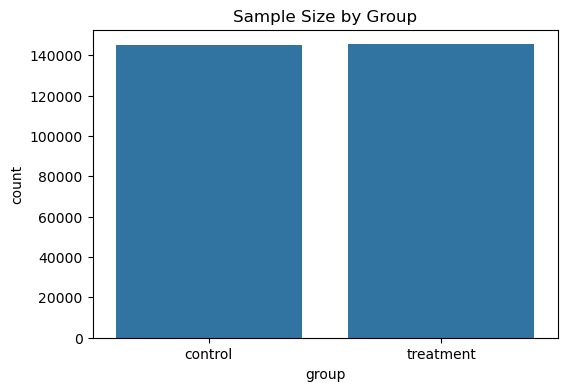

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x='group',data=df)

plt.title("Sample Size by Group")

plt.show()

In [21]:
#Step 7: Landing Page Assignment

#Check whether

#Control → Old Page

#Treatment → New Page

In [22]:
pd.crosstab(df.group,
            df.landing_page)

landing_page,new_page,old_page
group,,
control,1006,144226
treatment,144314,1038


In [23]:
#If mismatched rows exist:

In [24]:
df = df[((df.group=="control") &
         (df.landing_page=="old_page")) |
        ((df.group=="treatment") &
         (df.landing_page=="new_page"))]

In [25]:
#Step 8: Randomization Check

In [26]:
df.groupby("group")["converted"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control,144226.0,0.120290,0.325302,0.0,0.0,0.0,0.0,1.0
treatment,144314.0,0.118727,0.323468,0.0,0.0,0.0,0.0,1.0


In [27]:
#Phase 2 – Statistical Testing
#Step 1: Conversion Rate

In [28]:
conversion=df.groupby("group")["converted"].mean()

conversion

group
control      0.120290
treatment    0.118727
Name: converted, dtype: float64

In [29]:
#Visualization

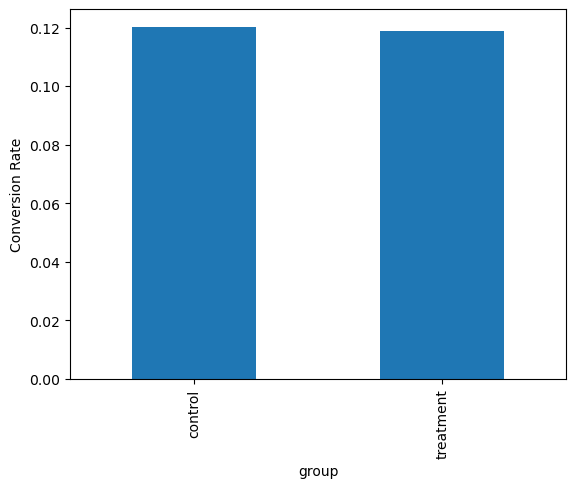

In [30]:
conversion.plot(kind='bar')

plt.ylabel("Conversion Rate")

plt.show()

In [31]:
#Step 2: Chi-Square Test

#Create Contingency Table

In [32]:
table=pd.crosstab(df.group,
                  df.converted)

table

converted,0,1
group,,
control,126877,17349
treatment,127180,17134


In [33]:
#Run Test

In [34]:
chi2,p,dof,expected=chi2_contingency(table)

print("Chi Square :",chi2)

print("P-value :",p)

Chi Square : 1.6602265966517187
P-value : 0.19757273201400033


In [35]:
#Decision

In [36]:
alpha=0.05

if p<alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [37]:
#Step 3: Two-Proportion Z-Test

In [38]:
from statsmodels.stats.proportion import proportions_ztest

success=np.array([
    df[df.group=="control"]["converted"].sum(),
    df[df.group=="treatment"]["converted"].sum()
])

sample=np.array([
    len(df[df.group=="control"]),
    len(df[df.group=="treatment"])
])

z,p=proportions_ztest(success,sample)

print(z,p)

1.2942367891190543 0.19558364287881436


In [39]:
#Decision

In [40]:
if p<0.05:
    print("Treatment significantly improves conversion.")
else:
    print("No significant improvement.")

No significant improvement.


In [41]:
#Step 4: Confidence Interval

#Conversion Rates

In [42]:
control=df[df.group=="control"]["converted"]

treatment=df[df.group=="treatment"]["converted"]

In [43]:
#Mean

In [44]:
control.mean()

treatment.mean()

np.float64(0.11872721981235362)

In [45]:
#Standard Error

In [46]:
def confidence_interval(series):

    n=len(series)

    p=series.mean()

    se=np.sqrt((p*(1-p))/n)

    lower=p-1.96*se

    upper=p+1.96*se

    return lower,upper

print(confidence_interval(control))

print(confidence_interval(treatment))

(np.float64(0.11861149856173041), np.float64(0.12196925664190832))
(np.float64(0.11705831269631443), np.float64(0.12039612692839281))


In [47]:
#Step 5: Absolute Lift

In [48]:
control_rate=control.mean()

treatment_rate=treatment.mean()

absolute_lift=treatment_rate-control_rate

print(absolute_lift)

-0.0015631577894657384


In [49]:
#Step 6: Relative Lift

In [50]:
relative_lift=(absolute_lift/control_rate)*100

print(relative_lift)

-1.299486975292441


In [52]:
#Phase 3 – Visualization

In [53]:
#1. Group Size

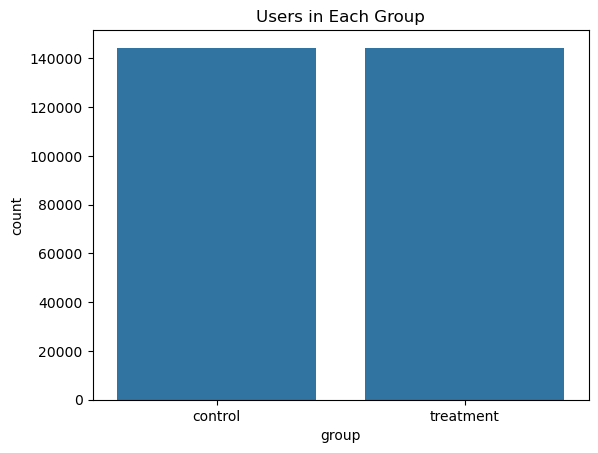

In [54]:
sns.countplot(data=df,
              x='group')

plt.title("Users in Each Group")

plt.show()

In [55]:
#2. Conversion Rate

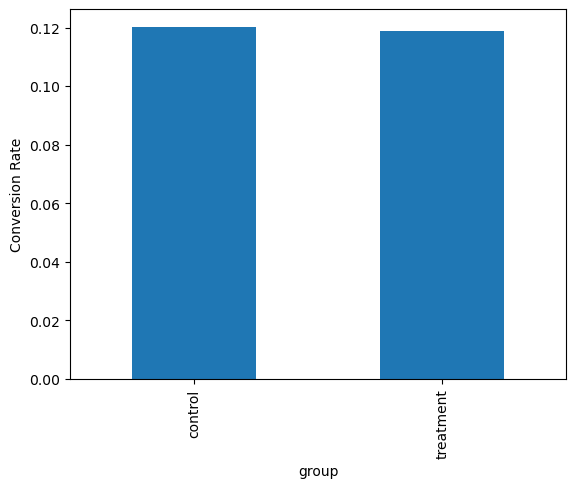

In [56]:
conversion.plot.bar()

plt.ylabel("Conversion Rate")

plt.show()

In [57]:
#3. Conversion Distribution

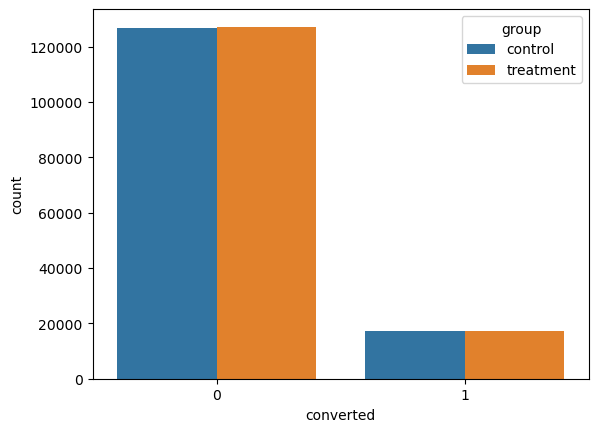

In [58]:
sns.countplot(data=df,
              x='converted',
              hue='group')

plt.show()

In [59]:
#4. Daily Traffic Trend

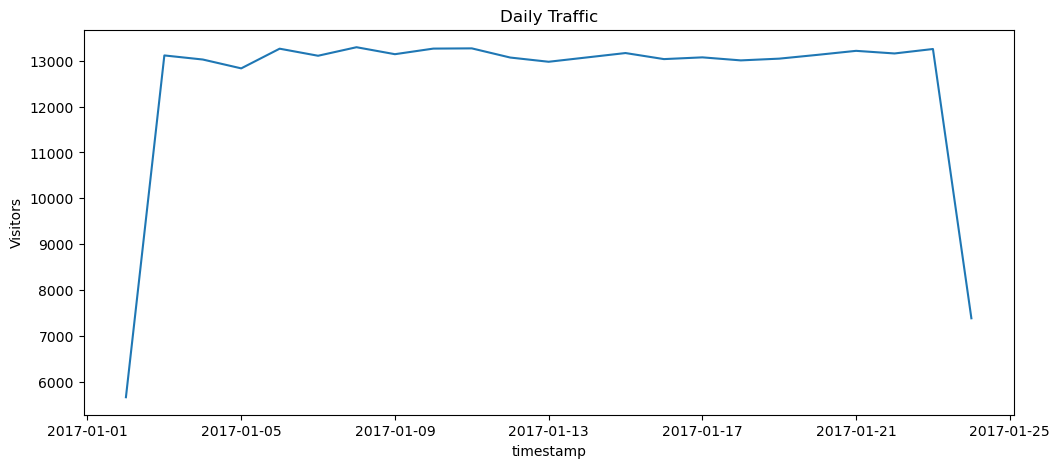

In [60]:
df['timestamp']=pd.to_datetime(df['timestamp'])

daily=df.groupby(df.timestamp.dt.date).size()

daily.plot(figsize=(12,5))

plt.ylabel("Visitors")

plt.title("Daily Traffic")

plt.show()

In [61]:
#5. Daily Conversion Trend

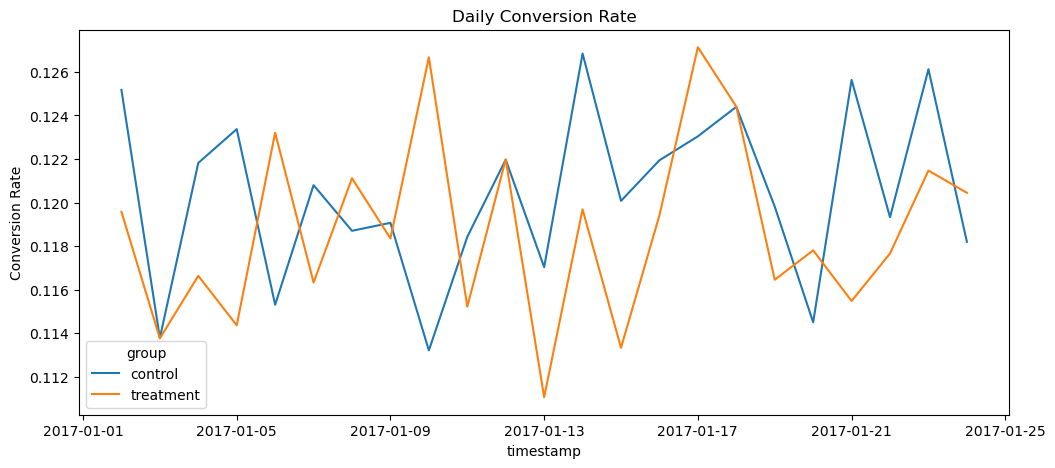

In [62]:
daily_conversion=df.groupby(
    [df.timestamp.dt.date,
     'group']
)['converted'].mean().unstack()

daily_conversion.plot(figsize=(12,5))

plt.ylabel("Conversion Rate")

plt.title("Daily Conversion Rate")

plt.show()